<a href="https://colab.research.google.com/github/DanendraPassadhi/PCVK/blob/main/PCVK_Week11_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Akses Drive

In [3]:
#Akses drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup Environtment

In [4]:
from google.colab import drive
import os

# Set base directory di Drive
BASE_DIR = "/content/drive/MyDrive/PCVK"  # Sesuaikan dengan folder Anda

# Path dataset
DATADIR_TRAIN = f"{BASE_DIR}/training"
DATADIR_TEST = f"{BASE_DIR}/testing1"

# Path untuk menyimpan hasil
OUTPUT_DIR = f"{BASE_DIR}/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Training data: {DATADIR_TRAIN}")
print(f"Testing data: {DATADIR_TEST}")
print(f"Output directory: {OUTPUT_DIR}\n")


Base directory: /content/drive/MyDrive/PCVK
Training data: /content/drive/MyDrive/PCVK/training
Testing data: /content/drive/MyDrive/PCVK/testing1
Output directory: /content/drive/MyDrive/PCVK/output



## Preprocessing Data

In [5]:
import cv2
import random
import numpy as np
import pickle
from tqdm import tqdm

print("=== Preprocessing Dataset dari Google Drive ===\n")

dirs = []
training_data = []
width, height = 100, 100

# Cek direktori training
if not os.path.exists(DATADIR_TRAIN):
    print(f"❌ ERROR: '{DATADIR_TRAIN}' tidak ditemukan!")
else:
    print(f"✓ Training directory found\n")

    # Ambil nama kelas dari folder
    for char_name in sorted(os.listdir(DATADIR_TRAIN)):
        char_path = os.path.join(DATADIR_TRAIN, char_name)
        if os.path.isdir(char_path):
            dirs.append(char_name)
            num_images = len([f for f in os.listdir(char_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"  Class '{char_name}': {num_images} images")

    print(f"\nTotal classes: {len(dirs)}")
    print(f"Classes: {dirs}\n")

    # Proses semua gambar training
    print("Processing training images from Drive...")
    for char_name in dirs:
        path = os.path.join(DATADIR_TRAIN, char_name)
        class_number = dirs.index(char_name)

        img_files = [f for f in os.listdir(path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        for img in tqdm(img_files, desc=f"Class {char_name}", unit="img"):
            try:
                img_path = os.path.join(path, img)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img_array is None:
                    continue

                new_array = cv2.resize(img_array, (width, height))
                training_data.append([new_array, class_number])

            except Exception as e:
                pass

    print(f"\n✓ Total processed: {len(training_data)} images")

    # Shuffle
    random.shuffle(training_data)

    # Pisahkan features dan labels
    X = []
    Y = []

    for feature, label in training_data:
        X.append(feature)
        Y.append(label)

    # Convert ke numpy array
    X = np.array(X).reshape(-1, width, height, 1)
    Y = np.array(Y)

    print(f"\nX shape: {X.shape}")
    print(f"Y shape: {Y.shape}")

    # Simpan ke Drive
    print(f"\nSaving pickle files to Drive ({OUTPUT_DIR})...")

    with open(f"{OUTPUT_DIR}/X.pickle", "wb") as f:
        pickle.dump(X, f)
    print("✓ X.pickle saved")

    with open(f"{OUTPUT_DIR}/Y.pickle", "wb") as f:
        pickle.dump(Y, f)
    print("✓ Y.pickle saved")

    with open(f"{OUTPUT_DIR}/class_mapping.pickle", "wb") as f:
        pickle.dump(dirs, f)
    print("✓ class_mapping.pickle saved")

    # Tampilkan distribusi
    print(f"\nClass distribution:")
    unique, counts = np.unique(Y, return_counts=True)
    for class_idx, count in zip(unique, counts):
        print(f"  {dirs[class_idx]}: {count} samples")

    print("\n✓ Preprocessing complete!")


=== Preprocessing Dataset dari Google Drive ===

✓ Training directory found

  Class '0': 850 images
  Class '1': 850 images
  Class '2': 850 images
  Class '3': 850 images
  Class '4': 850 images
  Class '5': 850 images
  Class '6': 850 images
  Class '7': 850 images
  Class '8': 850 images
  Class '9': 850 images

Total classes: 10
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Processing training images from Drive...


Class 9: 100%|██████████| 850/850 [00:24<00:00, 35.15img/s]



✓ Total processed: 8500 images

X shape: (8500, 100, 100, 1)
Y shape: (8500,)

Saving pickle files to Drive (/content/drive/MyDrive/PCVK/output)...
✓ X.pickle saved
✓ Y.pickle saved
✓ class_mapping.pickle saved

Class distribution:
  0: 850 samples
  1: 850 samples
  2: 850 samples
  3: 850 samples
  4: 850 samples
  5: 850 samples
  6: 850 samples
  7: 850 samples
  8: 850 samples
  9: 850 samples

✓ Preprocessing complete!


## Training Model

In [6]:
import pickle
import numpy as np
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("=== Training Model ===\n")

# Load pickle dari Drive
print("Loading data from Drive...")
with open(f"{OUTPUT_DIR}/X.pickle", "rb") as f:
    X = pickle.load(f)

with open(f"{OUTPUT_DIR}/Y.pickle", "rb") as f:
    Y = pickle.load(f)

with open(f"{OUTPUT_DIR}/class_mapping.pickle", "rb") as f:
    dirs = pickle.load(f)

print(f"✓ Data loaded")
print(f"  X shape: {X.shape}")
print(f"  Y shape: {Y.shape}")
print(f"  Classes: {dirs}\n")

# Preprocessing
X = X.astype('float32') / 255.0
num_classes = len(dirs)
Y = to_categorical(Y, num_classes=num_classes)

# Split train/validation
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train, Y_val = Y[:split_idx], Y[split_idx:]

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}\n")

# Build model
width, height = 100, 100
inputs = Input(shape=(width, height, 1))

conv_layer = ZeroPadding2D(padding=(2, 2))(inputs)
conv_layer = Conv2D(16, (5, 5), strides=(1, 1), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)

conv_layer = Conv2D(32, (3, 3), strides=(1, 1), activation='relu')(conv_layer)
conv_layer = Conv2D(32, (3, 3), strides=(1, 1), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)

conv_layer = Conv2D(64, (3, 3), strides=(1, 1), activation='relu')(conv_layer)

flatten = Flatten()(conv_layer)

fc_layer = Dense(256, activation='relu')(flatten)
fc_layer = Dropout(0.5)(fc_layer)
fc_layer = Dense(64, activation='relu')(fc_layer)
fc_layer = Dropout(0.3)(fc_layer)

outputs = Dense(num_classes, activation='softmax')(fc_layer)

adam = Adam(learning_rate=0.0001)
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks - simpan model terbaik ke Drive
callbacks = [
    ModelCheckpoint(
        f"{OUTPUT_DIR}/best_model.h5",  # Simpan ke Drive
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print("\nStarting training...")
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Simpan model final ke Drive
model.save(f"{OUTPUT_DIR}/anpr_model.h5")
print(f"\n✓ Model saved to Drive: {OUTPUT_DIR}/anpr_model.h5")

# Evaluasi
train_loss, train_acc = model.evaluate(X_train, Y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, Y_val, verbose=0)

print(f"\n=== Results ===")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# Simpan history ke Drive
with open(f"{OUTPUT_DIR}/training_history.pickle", "wb") as f:
    pickle.dump(history.history, f)
print(f"✓ Training history saved to Drive")


=== Training Model ===

Loading data from Drive...
✓ Data loaded
  X shape: (8500, 100, 100, 1)
  Y shape: (8500,)
  Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Train samples: 6800
Validation samples: 1700



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 104, 104, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,225,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,275,498 (27.75 MB)

 Trainable params: 7,275,498 (27.75 MB)

...

213/213 ━━━━━━━━━━━━━━━━━━━━ 142s 663ms/step - accuracy: 0.9913 - loss: 0.0251 - val_accuracy: 0.9976 - val_loss: 0.0095
Epoch 12/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9889 - loss: 0.0294
Epoch 12: val_accuracy did not improve from 0.99765
213/213 ━━━━━━━━━━━━━━━━━━━━ 136s 641ms/step - accuracy: 0.9889 - loss: 0.0294 - val_accuracy: 0.9965 - val_loss: 0.0122
Epoch 13/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9942 - loss: 0.0211
Epoch 13: val_accuracy improved from 0.99765 to 0.99824, saving model to /content/drive/MyDrive/PCVK/output/best_model.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 133s 626ms/step - accuracy: 0.9942 - loss: 0.0212 - val_accuracy: 0.9982 - val_loss: 0.0076
Epoch 14/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9943 - loss: 0.0175
Epoch 14: val_accuracy did not improve from 0.99824
213/213 ━━━━━━━━━━━━━━━━━━━━ 149s 659ms/step - accuracy: 0.9943 - loss: 0.0175 - val_accuracy: 0.9976 - val_loss: 0.0096
Epoch 15/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9906 - loss: 0.0213
Epoch 15: val_accuracy did not improve from 0.99824
213/213 ━━━━━━━━━━━━━━━━━━━━ 135s 632ms/step - accuracy: 0.9906 - loss: 0.0213 - val_accuracy: 0.9982 - val_loss: 0.0069
Epoch 16/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9919 - loss: 0.0217
Epoch 16: val_accuracy did not improve from 0.99824
213/213 ━━━━━━━━━━━━━━━━━━━━ 141s 628ms/step - accuracy: 0.9920 - loss: 0.0217 - val_accuracy: 0.9982 - val_loss: 0.0055
Epoch 17/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9942 - loss: 0.0160
Epoc

213/213 ━━━━━━━━━━━━━━━━━━━━ 135s 633ms/step - accuracy: 0.9958 - loss: 0.0133 - val_accuracy: 0.9988 - val_loss: 0.0039
Epoch 19/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9951 - loss: 0.0193
Epoch 19: val_accuracy did not improve from 0.99882
213/213 ━━━━━━━━━━━━━━━━━━━━ 135s 634ms/step - accuracy: 0.9951 - loss: 0.0193 - val_accuracy: 0.9982 - val_loss: 0.0053
Epoch 20/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9941 - loss: 0.0184
Epoch 20: val_accuracy improved from 0.99882 to 0.99941, saving model to /content/drive/MyDrive/PCVK/output/best_model.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 135s 632ms/step - accuracy: 0.9941 - loss: 0.0184 - val_accuracy: 0.9994 - val_loss: 0.0032
Restoring model weights from the end of the best epoch: 20.



✓ Model saved to Drive: /content/drive/MyDrive/PCVK/output/anpr_model.h5

=== Results ===
Train Accuracy: 99.97%
Validation Accuracy: 99.94%
✓ Training history saved to Drive


## Testing Model

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Memproses gambar KTM dari folder '/content/drive/MyDrive/PCVK/testing1'...

Processing: ktm.png

Jumlah digit terdeteksi: 10


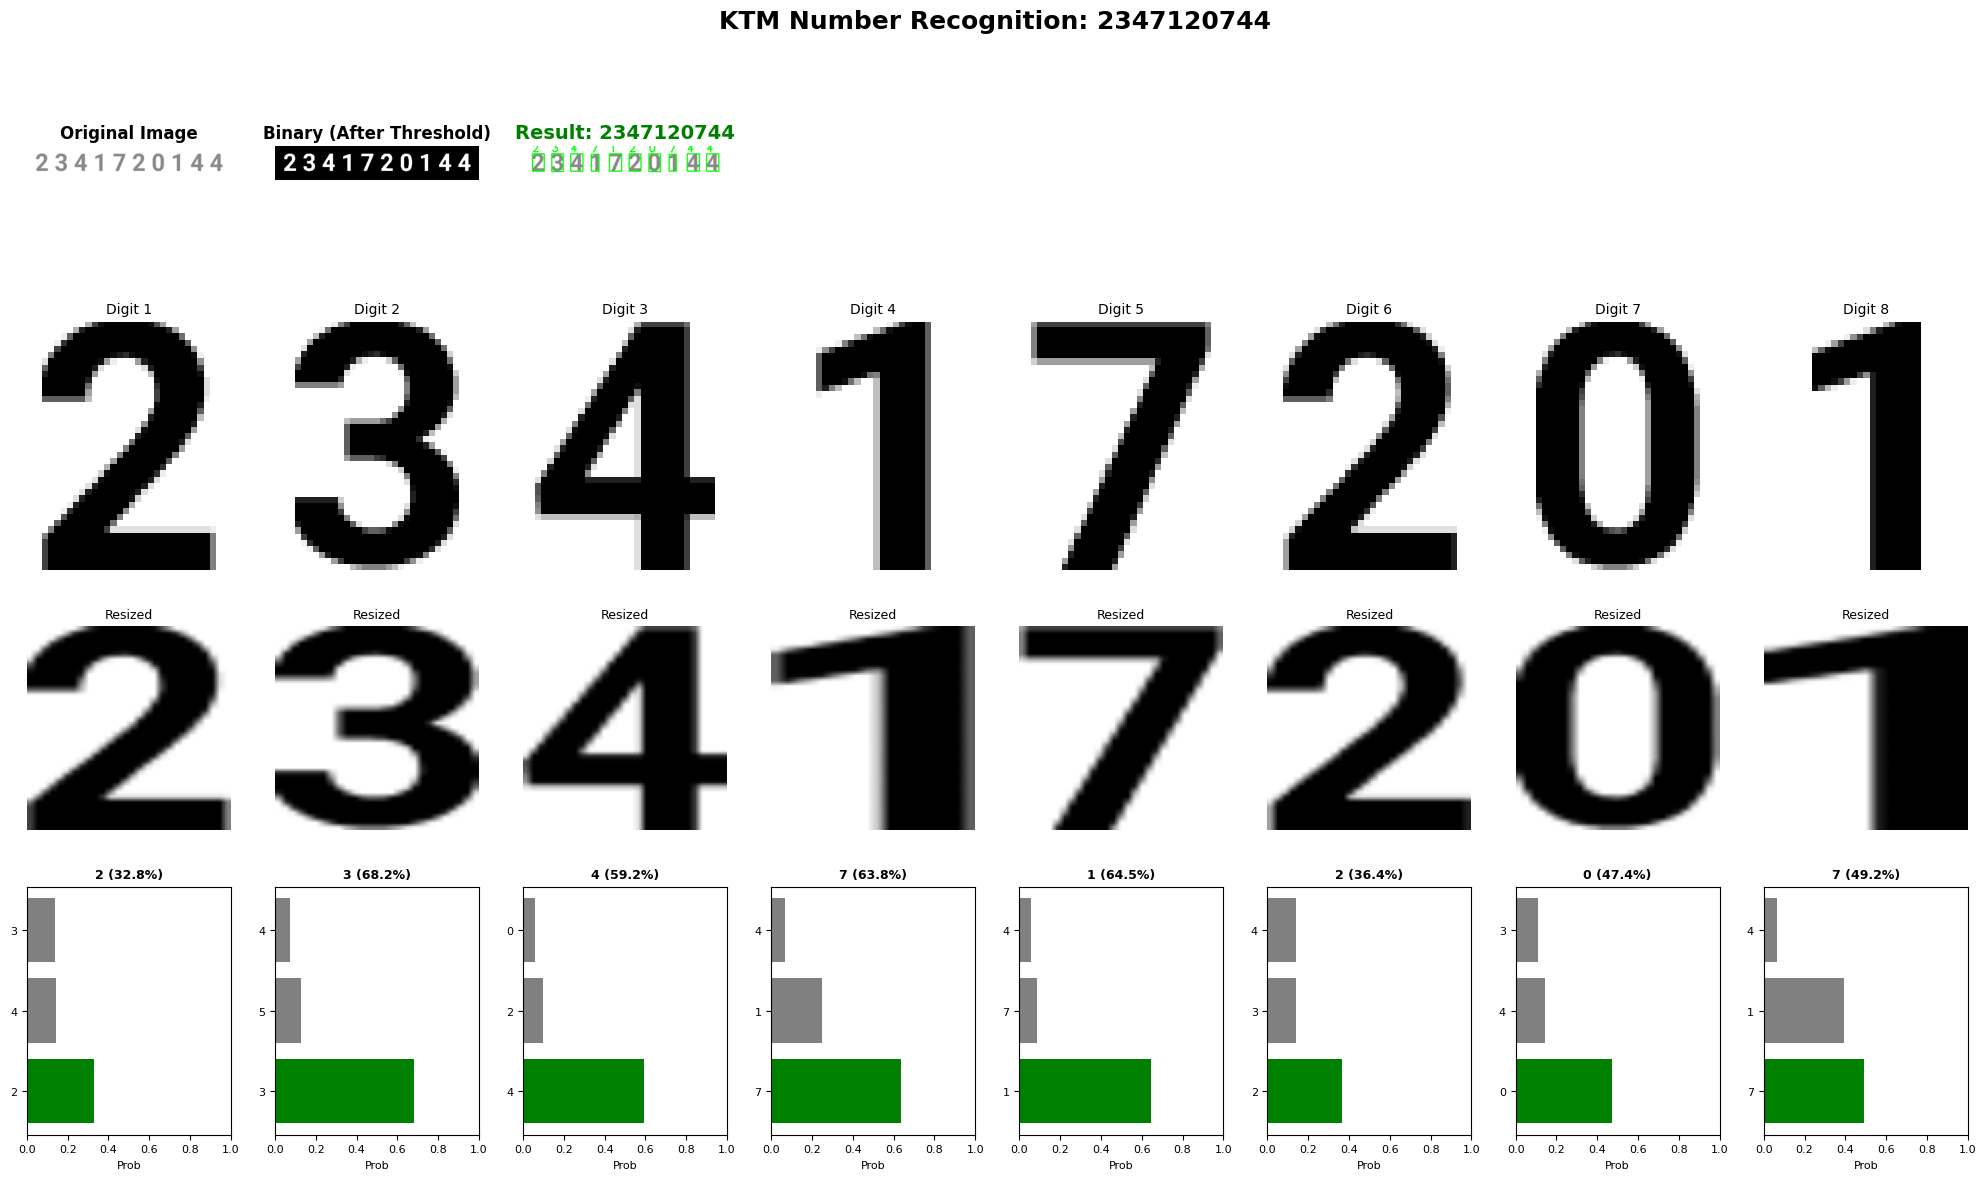


NOMOR KTM TERDETEKSI: 2347120744

Detail per digit:
  Digit 1: 2 (Confidence: 32.75%) 
  Digit 2: 3 (Confidence: 68.16%) 
  Digit 3: 4 (Confidence: 59.16%) 
  Digit 4: 7 (Confidence: 63.78%) 
  Digit 5: 1 (Confidence: 64.50%) 
  Digit 6: 2 (Confidence: 36.35%) 
  Digit 7: 0 (Confidence: 47.43%) 
  Digit 8: 7 (Confidence: 49.21%) 
  Digit 9: 4 (Confidence: 49.55%) 
  Digit 10: 4 (Confidence: 52.00%) 




In [67]:
import os
import cv2
import tensorflow as tf
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# Konfigurasi
OUTPUT_DIR = "/content/drive/MyDrive/PCVK/output"
data_dir_training = "/content/drive/MyDrive/PCVK/training"
width, height = 100, 100

# Load model
model = tf.keras.models.load_model(f"{OUTPUT_DIR}/anpr_model.h5")

# Load label names
dirs = []
for char_name in sorted(os.listdir(data_dir_training)):
    dirs.append(char_name)

print(f"Classes: {dirs}")

def segment_digits(image):
    """
    Segmentasi digit dari gambar KTM menggunakan contour detection
    Returns: list of digit images sorted from left to right
    """
    # Convert to grayscale jika diperlukan
    gray = image.copy()
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply thresholding untuk binary image
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological operations untuk cleaning noise
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Extract bounding boxes untuk setiap digit
    digit_boxes = []

    min_width = 5   # Lebar minimum kontur untuk dianggap digit
    min_height = 10 # Tinggi minimum kontur untuk dianggap digit
    min_area = 50   # Area minimum kontur untuk dianggap digit
    # --- END PARAMETER FILTERING --- #

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)

        # Filter berdasarkan ukuran (sesuaikan dengan ukuran digit di KTM)
        if w > min_width and h > min_height and area > min_area:
            digit_boxes.append((x, y, w, h))

    # Sort boxes dari kiri ke kanan (left to right)
    digit_boxes = sorted(digit_boxes, key=lambda box: box[0])

    # Extract digit images
    digit_images = []
    for (x, y, w, h) in digit_boxes:
        digit_img = gray[y:y+h, x:x+w]
        digit_images.append({
            'image': digit_img,
            'bbox': (x, y, w, h)
        })

    return digit_images, binary, gray

def predict_ktm_number():
    """
    Prediksi nomor KTM lengkap dari gambar
    """
    print("Memproses gambar KTM dari folder '/content/drive/MyDrive/PCVK/testing1'...")
    test_images_dir = "/content/drive/MyDrive/PCVK/testing/ktm_4"

    if not os.path.exists(test_images_dir):
        print(f"Error: Direktori '{test_images_dir}' tidak ditemukan.")
        return

    # Get all image files in the directory
    image_files = [os.path.join(test_images_dir, f)
                   for f in os.listdir(test_images_dir)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    if not image_files:
        print(f"Tidak ada file gambar yang ditemukan di '{test_images_dir}'.")
        return

    for filename in image_files:
        try:
            print(f"\n{'='*70}")
            print(f"Processing: {os.path.basename(filename)}")
            print(f"{'='*70}")

            # Read image
            image = cv2.imread(filename)

            # Segment digits dari gambar
            digit_images, binary, gray = segment_digits(image)

            num_digits = len(digit_images)
            print(f"\nJumlah digit terdeteksi: {num_digits}")

            if num_digits == 0:
                print("Tidak ada digit yang terdeteksi. Coba adjust threshold segmentation.")
                continue

            # Predict setiap digit
            predictions = []
            ktm_number = ""

            for i, digit_data in enumerate(digit_images):
                digit_img = digit_data['image']

                # Resize to model input size
                resized = cv2.resize(digit_img, (width, height))

                # Reshape dan normalisasi
                input_array = np.array(resized).reshape(-1, width, height, 1) / 255.0

                # Prediksi
                prediction = model.predict(input_array, verbose=0)
                predicted_class = np.argmax(prediction[0])
                confidence = np.max(prediction[0]) * 100

                predicted_digit = dirs[predicted_class]
                ktm_number += predicted_digit

                predictions.append({
                    'digit': predicted_digit,
                    'confidence': confidence,
                    'bbox': digit_data['bbox'],
                    'prediction_probs': prediction[0]
                })

            # ============ VISUALISASI ============ #
            # Hitung jumlah row yang dibutuhkan untuk visualisasi
            num_cols = min(num_digits, 8)  # maksimal 8 kolom
            num_rows = 4  # Original, Binary, Digit Segments, Predictions

            fig = plt.figure(figsize=(20, 12))

            # 1. Original Image
            ax1 = plt.subplot(num_rows, num_cols, 1)
            ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            ax1.set_title('Original Image', fontweight='bold', fontsize=12)
            ax1.axis('off')

            # 2. Binary Image (Preprocessed)
            ax2 = plt.subplot(num_rows, num_cols, 2)
            ax2.imshow(binary, cmap='gray')
            ax2.set_title('Binary (After Threshold)', fontweight='bold', fontsize=12)
            ax2.axis('off')

            # 3. Image dengan bounding boxes
            result_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).copy()
            for pred in predictions:
                x, y, w, h = pred['bbox']
                cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(result_img, pred['digit'], (x, y-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

            ax3 = plt.subplot(num_rows, num_cols, 3)
            ax3.imshow(result_img)
            ax3.set_title(f'Result: {ktm_number}', fontweight='bold', fontsize=14, color='green')
            ax3.axis('off')

            # 4. Tampilkan setiap segmented digit
            for i, digit_data in enumerate(digit_images):
                if i < num_cols:
                    # Segmented digit
                    ax = plt.subplot(num_rows, num_cols, num_cols + i + 1)
                    ax.imshow(digit_data['image'], cmap='gray')
                    ax.set_title(f'Digit {i+1}', fontsize=10)
                    ax.axis('off')

                    # Resized digit
                    resized = cv2.resize(digit_data['image'], (width, height))
                    ax = plt.subplot(num_rows, num_cols, 2*num_cols + i + 1)
                    ax.imshow(resized, cmap='gray')
                    ax.set_title(f'Resized', fontsize=9)
                    ax.axis('off')

                    # Prediction bar chart
                    ax = plt.subplot(num_rows, num_cols, 3*num_cols + i + 1)
                    pred = predictions[i]

                    # Top 3 predictions
                    top_3_idx = np.argsort(pred['prediction_probs'])[-3:][::-1]
                    top_3_probs = pred['prediction_probs'][top_3_idx]
                    top_3_labels = [dirs[idx] for idx in top_3_idx]

                    colors = ['green' if idx == 0 else 'gray' for idx in range(3)]
                    ax.barh(top_3_labels, top_3_probs, color=colors)
                    ax.set_xlabel('Prob', fontsize=8)
                    ax.set_title(f'{pred["digit"]} ({pred["confidence"]:.1f}%)',
                                fontsize=9, fontweight='bold')
                    ax.set_xlim([0, 1])
                    ax.tick_params(labelsize=8)

            plt.suptitle(f'KTM Number Recognition: {ktm_number}',
                        fontsize=18, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()

            # ============ PRINT RESULTS ============ #
            print(f"\n{'='*70}")
            print(f"NOMOR KTM TERDETEKSI: {ktm_number}")
            print(f"{'='*70}\n")

            print("Detail per digit:")
            for i, pred in enumerate(predictions, 1):
                print(f"  Digit {i}: {pred['digit']} (Confidence: {pred['confidence']:.2f}%) ")

            print(f"\n{'='*70}\n")

        except Exception as e:
            print(f"Error processing {filename}: {e}")
            import traceback
            traceback.print_exc()

# Jalankan fungsi
predict_ktm_number()

## Kesimpulan
Hasil pengujian telah menunjukkan performa yang cukup baik. Meskipun demikian, masih terdeteksi kebingungan antara angka 7 dan angka 1, di mana keduanya sering terbaca atau terprediksi secara terbalik.

Hal ini kemungkinan besar disebabkan oleh kurangnya variasi dan representasi data yang memadai dalam dataset yang digunakan untuk pelatihan model.